# Mode Choice Prediction in Switzerland

## Reading the dataset

The data is presented as `txt` file, with tabulated columns.


In [55]:
import pandas as pd

dataset = pd.read_csv("ModeChoiceOptima.txt", sep="\t")

dataset

,ID,DestAct,NbTransf,TimePT,WalkingTimePT,WaitingTimePT,CostPT,CostCar,TimeCar,NbHousehold,...,FreqTripHouseh,Region,distance_km,Choice,InVehicleTime,ModeToSchool,ReportedDuration,CoderegionCAR,age,Weight
0,10350017,2,4,85,23,10,12.4,3.17,32,2,...,4,1,30.0,1,52,3,255,1,27,0.000379
1,10350020,1,4,108,26,16,12.4,3.28,30,2,...,4,1,32.0,-1,66,3,150,1,28,0.000341
2,10350025,11,2,82,33,5,3.0,0.45,6,-1,...,2,1,4.5,0,44,-1,20,1,-1,0.000368
3,10350075,1,3,107,21,31,24.0,2.36,23,2,...,1,1,25.0,1,55,-1,30,1,63,0.000368
4,10350085,1,5,190,116,18,10.8,1.16,14,3,...,3,1,12.5,1,56,-1,20,1,57,0.000409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260,96040535,1,6,299,84,94,48.8,10.72,86,1,...,1,7,119.0,-1,121,6,90,7,51,0.000409
2261,96040537,8,0,139,116,0,14.4,3.18,43,5,...,3,7,32.0,1,23,5,70,7,46,0.000368
2262,96040537,8,0,71,57,0,6.0,0.94,12,5,...,3,7,9.0,1,14,5,20,7,46,0.000368
2263,96040538,11,2,118,70,10,11.4,1.77,24,5,...,4,7,17.5,1,38,3,30,7,49,0.000409


Five different datasets are to be analyzed, based on:

1. Structural features
2. Socio-economics features
3. Attitudinal features
4. All of the above


### Create Training & Validation Data


In [56]:
from enum import Enum
import numpy as np


class FeatureType(Enum):
    Numerical = 1
    Ordinal = 2
    Nominal = 3


structural_features = [
    ("NbTransf", FeatureType.Numerical),
    ("TimePT", FeatureType.Numerical),
    ("WalkingTimePT", FeatureType.Numerical),
    ("WaitingTimePT", FeatureType.Numerical),
    ("TimeCar", FeatureType.Numerical),
    ("CostPT", FeatureType.Numerical),
    ("MarginalCostPT", FeatureType.Numerical),
    ("CostCar", FeatureType.Numerical),
    ("TripPurpose", FeatureType.Nominal),
    ("TypeCommune", FeatureType.Nominal),
    ("ClassifCodeLine", FeatureType.Nominal),
    ("frequency", FeatureType.Ordinal),
    ("NbTrajects", FeatureType.Numerical),
    ("distance_km", FeatureType.Numerical),
    ("DestAct", FeatureType.Nominal),
    ("FreqTripHouseh", FeatureType.Ordinal),
]

socio_features = [
    ("age", FeatureType.Numerical),
    ("ModeToSchool", FeatureType.Nominal),
    ("ResidChild", FeatureType.Nominal),
    ("NbHousehold", FeatureType.Numerical),
    ("NbChild", FeatureType.Numerical),
    ("NbCar", FeatureType.Numerical),
    ("NbMoto", FeatureType.Numerical),
    ("NbBicy", FeatureType.Numerical),
    ("NbBicyChild", FeatureType.Numerical),
    ("NbComp", FeatureType.Numerical),
    ("NbTV", FeatureType.Numerical),
    ("Internet", FeatureType.Nominal),
    ("NewsPaperSubs", FeatureType.Nominal),
    ("NbCellPhones", FeatureType.Numerical),
    ("NbSmartPhone", FeatureType.Numerical),
    ("HouseType", FeatureType.Nominal),
    ("Income", FeatureType.Ordinal),
    ("Gender", FeatureType.Nominal),
    ("Mothertongue", FeatureType.Nominal),
    ("FamilSitu", FeatureType.Nominal),
    ("OccupStat", FeatureType.Nominal),
    ("SocioProfCat", FeatureType.Nominal),
    ("Education", FeatureType.Ordinal),
]

attitudinal_features = (
    [(f"Envir{str(i).zfill(2)}", FeatureType.Ordinal) for i in range(1, 7)]
    + [(f"Mobil{str(i).zfill(2)}", FeatureType.Ordinal) for i in range(1, 28)]
    + [(f"ResidCh{str(i).zfill(2)}", FeatureType.Ordinal) for i in range(1, 8)]
    + [(f"LifSty{str(i).zfill(2)}", FeatureType.Ordinal) for i in range(1, 15)]
)

global_features = structural_features + socio_features + attitudinal_features

features_groups = {
    "Structural": structural_features,
    "Socio": socio_features,
    "Attitudinal": attitudinal_features,
    "Global": global_features,
}


df = dataset[[f for f, _ in global_features] + ["Choice"]]
original_size = len(df)

missing_choice = df["Choice"] < 0
# Drop rows with missing target variable
df.drop(df[missing_choice].index, inplace=True)

# Drop rows with missing features (negative values)
for feature, _ in global_features + [("Choice", FeatureType.Nominal)]:
    missing = df[feature] < 0
    df.drop(df[missing].index, inplace=True)

# Set all attitudinal features = 6 ("Don't know") to 3 ("Neutral")
# as removing them would lead to a significant loss of data
for feature, _ in attitudinal_features:
    invalid = df[feature] == 6
    df.loc[invalid, feature] = 3

rows_dropped = original_size - len(df)
print(f"Dropped {rows_dropped} rows.")
print(f"Dataset size after dropping: {len(df)} rows")

print(f"Features groups:")
for group, features in features_groups.items():
    print(f"- {group}: {len(features)} features")

Dropped 1148 rows.
Dataset size after dropping: 1117 rows
Features groups:
- Structural: 16 features
- Socio: 23 features
- Attitudinal: 54 features
- Global: 93 features


In [57]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Choice"])
y = df["Choice"]

# Training: Fitting model weights
# Validation: Comparing models, tuning
# Test: Final evaluation of the best model on unseen data

validation_size = 0.2
test_size = 0.2

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=(test_size + validation_size),
    random_state=42,
    stratify=y,  # Make sure enough samples of each class are in both sets
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=test_size
    / (test_size + validation_size),  # Proportion of test size relative to the temp set
    random_state=42,
    stratify=y_temp,
)

print(f"Training set size: {len(X_train)} rows")
print(f"Validation set size: {len(X_val)} rows")
print(f"Test set size: {len(X_test)} rows")

Training set size: 670 rows
Validation set size: 223 rows
Test set size: 224 rows


## Prepare Pipelines


In [58]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


get_preprocessor = lambda features: ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            [
                f
                for f, t in features
                if t == FeatureType.Numerical or t == FeatureType.Ordinal
            ],
        ),
        (
            "nom",
            OneHotEncoder(
                # Get all possible categories from the whole dataset to avoid issues with unseen categories in the validation/test sets
                categories=[
                    sorted(X[f].unique().tolist())
                    for f, t in features
                    if t == FeatureType.Nominal
                ],
                sparse_output=False,
            ),
            [f for f, t in features if t == FeatureType.Nominal],
        ),
    ]
)

get_pipeline = lambda features, classifier: Pipeline(
    steps=[
        ("preprocessor", get_preprocessor(features)),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("classifier", classifier),
    ]
)

## Define Classifiers


In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier


classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=10_000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "XGBoost": GradientBoostingClassifier(random_state=42),
    "Neural Network": MLPClassifier(
        random_state=42, max_iter=1000, hidden_layer_sizes=(20, 5)
    ),
}

## Train Models


In [61]:
from sklearn.metrics import accuracy_score, log_loss

for group_name, features in features_groups.items():
    print(f"Evaluating classifiers on {group_name} features...")
    for clf_name, clf in classifiers.items():
        pipeline = get_pipeline(features, clf)
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        y_pred_proba = pipeline.predict_proba(X_val)

        acc = accuracy_score(y_val, y_pred)
        ll = log_loss(y_val, y_pred_proba)

        print(f"- {clf_name:25s}: Accuracy = {acc:.4f}, Log Loss = {ll:.4f}")

Evaluating classifiers on Structural features...
- Logistic Regression      : Accuracy = 0.6592, Log Loss = 0.7504
- Decision Tree            : Accuracy = 0.7175, Log Loss = 6.4515
- XGBoost                  : Accuracy = 0.7623, Log Loss = 0.5351
- Neural Network           : Accuracy = 0.7354, Log Loss = 2.6607
Evaluating classifiers on Socio features...
- Logistic Regression      : Accuracy = 0.5516, Log Loss = 1.0691
- Decision Tree            : Accuracy = 0.6457, Log Loss = 7.2277
- XGBoost                  : Accuracy = 0.6816, Log Loss = 0.7388
- Neural Network           : Accuracy = 0.6637, Log Loss = 2.8758
Evaluating classifiers on Attitudinal features...
- Logistic Regression      : Accuracy = 0.6906, Log Loss = 0.9007
- Decision Tree            : Accuracy = 0.6368, Log Loss = 11.2330
- XGBoost                  : Accuracy = 0.7623, Log Loss = 0.6450
- Neural Network           : Accuracy = 0.7040, Log Loss = 3.0262
Evaluating classifiers on Global features...
- Logistic Regressi

# OLD

### Classifier Plots


In [ ]:
from matplotlib import pyplot as plt


def plot_models_score(
    structural_score,
    socio_score,
    attitudinal_score,
    global_score,
    classifier_name="Model",
):
    plt.figure(figsize=(4, 3))
    labels = ["Structural", "Socio", "Attitudinal", "Global"]
    scores = [structural_score, socio_score, attitudinal_score, global_score]
    plt.bar(labels, scores, color=["tab:blue", "tab:orange", "tab:green", "tab:red"])
    # Add score values on top of the bars
    for i, score in enumerate(scores):
        plt.text(i, score + 0.01, f"{score:.2f}", ha="center", va="bottom")
    plt.ylim(0, 1)
    plt.ylabel("F1 Score")
    plt.title(f"{classifier_name} Performance Comparison")
    plt.show()

### Multinomial Logistic Regression


Structural features accuracy: 0.7435
Socio features accuracy: 0.5913
Attitudinal features accuracy: 0.6348
Global features accuracy: 0.8043


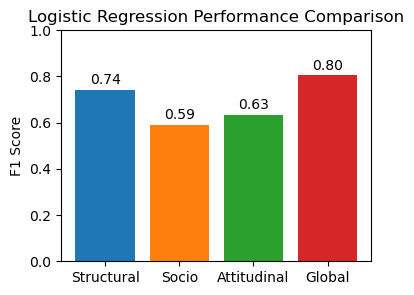

In [ ]:
get_classifier = lambda: LogisticRegression(max_iter=10_000)

lr_structural_pipeline = get_pipeline(structural_features, get_classifier())
lr_socio_pipeline = get_pipeline(socio_features, get_classifier())
lr_attitudinal_pipeline = get_pipeline(attitudinal_features, get_classifier())
lr_global_pipeline = get_pipeline(global_features, get_classifier())

lr_structural_pipeline.fit(X_train, y_train)
lr_socio_pipeline.fit(X_train, y_train)
lr_attitudinal_pipeline.fit(X_train, y_train)
lr_global_pipeline.fit(X_train, y_train)

lr_structural_score = lr_structural_pipeline.score(X_test, y_test)
lr_socio_score = lr_socio_pipeline.score(X_test, y_test)
lr_attitudinal_score = lr_attitudinal_pipeline.score(X_test, y_test)
lr_global_score = lr_global_pipeline.score(X_test, y_test)

print(f"Structural features accuracy: {lr_structural_score:.4f}")
print(f"Socio features accuracy: {lr_socio_score:.4f}")
print(f"Attitudinal features accuracy: {lr_attitudinal_score:.4f}")
print(f"Global features accuracy: {lr_global_score:.4f}")

plot_models_score(
    lr_structural_score,
    lr_socio_score,
    lr_attitudinal_score,
    lr_global_score,
    classifier_name="Logistic Regression",
)

### Decision Tree Classifier


Structural features accuracy: 0.7348
Socio features accuracy: 0.6957
Attitudinal features accuracy: 0.6870
Global features accuracy: 0.7739


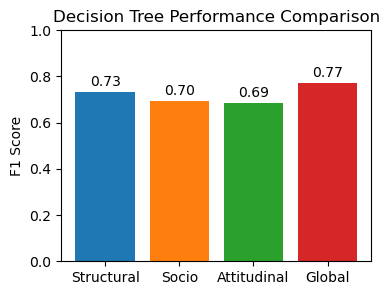

In [ ]:
get_classifier = lambda: DecisionTreeClassifier()

dt_structural_pipeline = get_pipeline(structural_features, get_classifier())
dt_socio_pipeline = get_pipeline(socio_features, get_classifier())
dt_attitudinal_pipeline = get_pipeline(attitudinal_features, get_classifier())
dt_global_pipeline = get_pipeline(global_features, get_classifier())

dt_structural_pipeline.fit(X_train, y_train)
dt_socio_pipeline.fit(X_train, y_train)
dt_attitudinal_pipeline.fit(X_train, y_train)
dt_global_pipeline.fit(X_train, y_train)

dt_structural_score = dt_structural_pipeline.score(X_test, y_test)
dt_socio_score = dt_socio_pipeline.score(X_test, y_test)
dt_attitudinal_score = dt_attitudinal_pipeline.score(X_test, y_test)
dt_global_score = dt_global_pipeline.score(X_test, y_test)

print(f"Structural features accuracy: {dt_structural_score:.4f}")
print(f"Socio features accuracy: {dt_socio_score:.4f}")
print(f"Attitudinal features accuracy: {dt_attitudinal_score:.4f}")
print(f"Global features accuracy: {dt_global_score:.4f}")

plot_models_score(
    dt_structural_score,
    dt_socio_score,
    dt_attitudinal_score,
    dt_global_score,
    classifier_name="Decision Tree",
)

### XGBoost


Structural features accuracy: 0.8304
Socio features accuracy: 0.7130
Attitudinal features accuracy: 0.7957
Global features accuracy: 0.8783


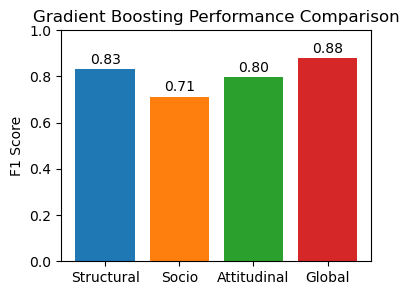

In [ ]:
get_classifier = lambda: GradientBoostingClassifier()

xgboost_structural_pipeline = get_pipeline(structural_features, get_classifier())
xgboost_socio_pipeline = get_pipeline(socio_features, get_classifier())
xgboost_attitudinal_pipeline = get_pipeline(attitudinal_features, get_classifier())
xgboost_global_pipeline = get_pipeline(global_features, get_classifier())

xgboost_structural_pipeline.fit(X_train, y_train)
xgboost_socio_pipeline.fit(X_train, y_train)
xgboost_attitudinal_pipeline.fit(X_train, y_train)
xgboost_global_pipeline.fit(X_train, y_train)

xgboost_structural_score = xgboost_structural_pipeline.score(X_test, y_test)
xgboost_socio_score = xgboost_socio_pipeline.score(X_test, y_test)
xgboost_attitudinal_score = xgboost_attitudinal_pipeline.score(X_test, y_test)
xgboost_global_score = xgboost_global_pipeline.score(X_test, y_test)

print(f"Structural features accuracy: {xgboost_structural_score:.4f}")
print(f"Socio features accuracy: {xgboost_socio_score:.4f}")
print(f"Attitudinal features accuracy: {xgboost_attitudinal_score:.4f}")
print(f"Global features accuracy: {xgboost_global_score:.4f}")

plot_models_score(
    xgboost_structural_score,
    xgboost_socio_score,
    xgboost_attitudinal_score,
    xgboost_global_score,
    classifier_name="Gradient Boosting",
)

### Neural Networks


Structural features accuracy: 0.7391
Socio features accuracy: 0.6826
Attitudinal features accuracy: 0.6870
Global features accuracy: 0.7609


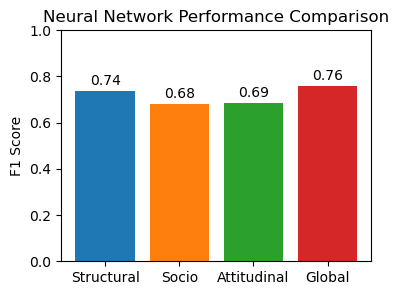

In [ ]:
layers = (20, 5)

get_classifier = lambda: MLPClassifier(
    solver="lbfgs", max_iter=10_000, hidden_layer_sizes=layers, random_state=42
)

nn_structural_pipeline = get_pipeline(structural_features, get_classifier())
nn_socio_pipeline = get_pipeline(socio_features, get_classifier())
nn_attitudinal_pipeline = get_pipeline(attitudinal_features, get_classifier())
nn_global_pipeline = get_pipeline(global_features, get_classifier())

nn_structural_pipeline.fit(X_train, y_train)
nn_socio_pipeline.fit(X_train, y_train)
nn_attitudinal_pipeline.fit(X_train, y_train)
nn_global_pipeline.fit(X_train, y_train)

nn_structural_score = nn_structural_pipeline.score(X_test, y_test)
nn_socio_score = nn_socio_pipeline.score(X_test, y_test)
nn_attitudinal_score = nn_attitudinal_pipeline.score(X_test, y_test)
nn_global_score = nn_global_pipeline.score(X_test, y_test)

print(f"Structural features accuracy: {nn_structural_score:.4f}")
print(f"Socio features accuracy: {nn_socio_score:.4f}")
print(f"Attitudinal features accuracy: {nn_attitudinal_score:.4f}")
print(f"Global features accuracy: {nn_global_score:.4f}")

plot_models_score(
    nn_structural_score,
    nn_socio_score,
    nn_attitudinal_score,
    nn_global_score,
    classifier_name="Neural Network",
)

## SHAP


In [ ]:
import shap

# Extract classifiers and preprocessors from pipelines
lr_preprocessor = lr_global_pipeline.named_steps["preprocessor"]
dt_preprocessor = dt_global_pipeline.named_steps["preprocessor"]
xgboost_preprocessor = xgboost_global_pipeline.named_steps["preprocessor"]
nn_preprocessor = nn_global_pipeline.named_steps["preprocessor"]

lr_classifier = lr_global_pipeline.named_steps["classifier"]
dt_classifier = dt_global_pipeline.named_steps["classifier"]
xgboost_classifier = xgboost_global_pipeline.named_steps["classifier"]
nn_classifier = nn_global_pipeline.named_steps["classifier"]

# Transform data using preprocessors
feature_names = (
    lr_preprocessor.get_feature_names_out()
)  # same for all if pipeline is identical

X_train_lr = pd.DataFrame(lr_preprocessor.transform(X_train), columns=feature_names)
X_test_lr = pd.DataFrame(lr_preprocessor.transform(X_test), columns=feature_names)

X_train_dt = pd.DataFrame(dt_preprocessor.transform(X_train), columns=feature_names)
X_test_dt = pd.DataFrame(dt_preprocessor.transform(X_test), columns=feature_names)

X_train_xgb = pd.DataFrame(
    xgboost_preprocessor.transform(X_train), columns=feature_names
)
X_test_xgb = pd.DataFrame(xgboost_preprocessor.transform(X_test), columns=feature_names)

X_train_nn = pd.DataFrame(nn_preprocessor.transform(X_train), columns=feature_names)
X_test_nn = pd.DataFrame(nn_preprocessor.transform(X_test), columns=feature_names)


# Create SHAP explainers for each model
background = shap.sample(X_train_nn, nsamples=100)

lr_explainer = shap.LinearExplainer(lr_classifier, X_train_lr)
dt_explainer = shap.TreeExplainer(dt_classifier)
xgboost_explainer = shap.KernelExplainer(xgboost_classifier.predict_proba, background)
nn_explainer = shap.KernelExplainer(nn_classifier.predict_proba, background)

shap_values_lr = lr_explainer(X_test_lr)
shap_values_dt = dt_explainer(X_test_dt)
shap_values_xgboost = xgboost_explainer(X_test_xgb)
shap_values_nn = nn_explainer(X_test_nn.values)

  0%|          | 0/230 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

### Logistic Regression Analysis


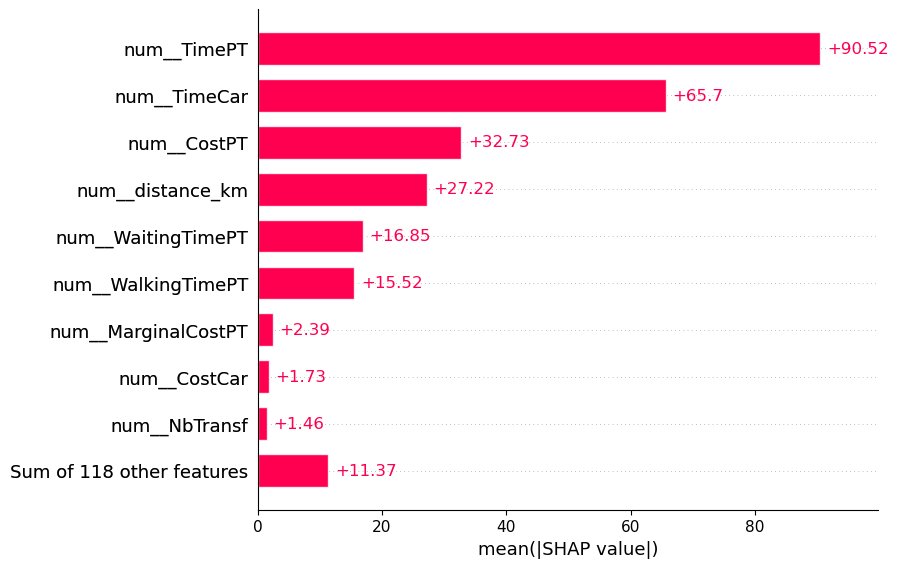

In [ ]:
shap.plots.bar(shap_values_lr[:, :, 0])

### Decision Tree Analysis


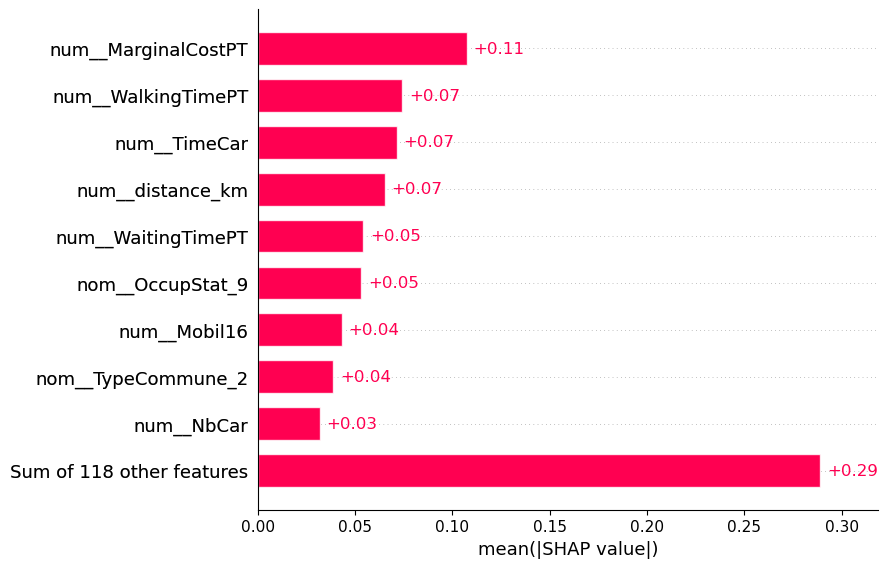

In [ ]:
shap.plots.bar(shap_values_dt[:, :, 0])

### XGBoost Analysis


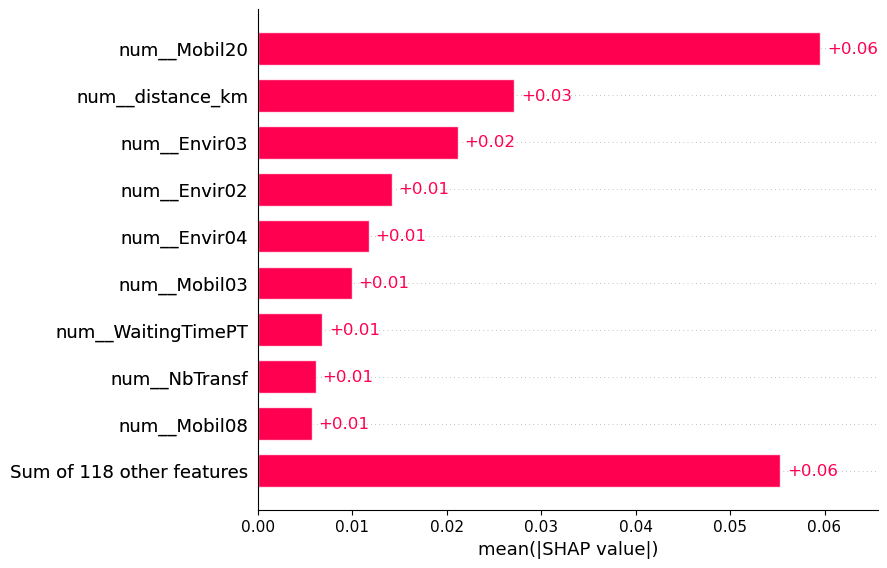

In [ ]:
shap.plots.bar(shap_values_xgboost[:, :, 0])

### Neural Network Analysis


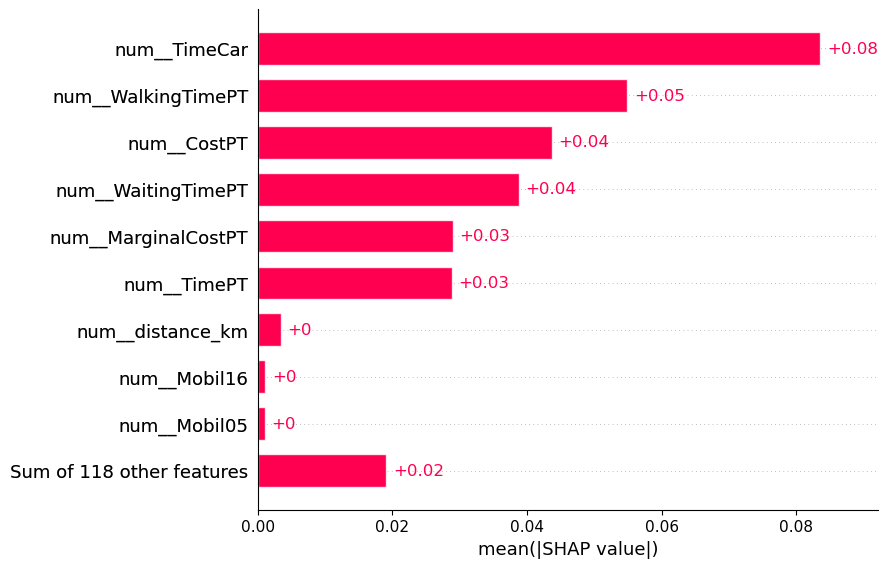

In [ ]:
shap.plots.bar(shap_values_nn[:, :, 0])